In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd

import torch
from torch.utils.data import DataLoader
import torch.nn as nn

import matplotlib.pyplot as plt

# ---------- Find project root ----------

def find_project_root(start: Path) -> Path:
    """
    Walk upwards from `start` until we find a directory that has 'src' and 'data'.
    """
    cur = start.resolve()
    for p in [cur] + list(cur.parents):
        if (p / "src").is_dir() and (p / "data").is_dir():
            return p
    raise RuntimeError(f"Could not find project root starting from {start}")

project_root = find_project_root(Path.cwd())
print("PROJECT_ROOT:", project_root)

# Make sure src/ is importable
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))
print("project_root in sys.path:", str(project_root) in sys.path)

# ---------- Imports from your code ----------

from src.models import DomainCNN
from src.datasets import DomainClassificationDataset, pad_collate_fn

# ---------- Paths ----------

META_DIR = project_root / "data" / "processed" / "metadata"
CSV_ORIG = META_DIR / "domain_classification_sentences.csv"
CSV_A4   = META_DIR / "domain_classification_sentences_A4_emuru_realistic.csv"

CKPT_BASELINE = project_root / "checkpoints" / "domain_cnn_best.pt"
CKPT_A1       = project_root / "checkpoints" / "domain_cnn_best_A1_geo.pt"
CKPT_A2       = project_root / "checkpoints" / "domain_cnn_best_A2_photo.pt"
CKPT_A3       = project_root / "checkpoints" / "domain_cnn_best_A3_norm.pt"
CKPT_A4       = project_root / "checkpoints" / "domain_cnn_best_A4_emuru_realistic.pt"

print("CSV_ORIG:", CSV_ORIG)
print("CSV_A4  :", CSV_A4)
print("Baseline ckpt:", CKPT_BASELINE)
print("A1 ckpt      :", CKPT_A1)
print("A2 ckpt      :", CKPT_A2)
print("A3 ckpt      :", CKPT_A3)
print("A4 ckpt      :", CKPT_A4)

# ---------- Device ----------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ---------- Helper: evaluate ONE model (you'll CALL this per-model in separate cells) ----------

def evaluate_model_on_test(
    label: str,
    csv_path: Path,
    checkpoint_path: Path,
    normalize_all: bool = False,
    batch_size: int = 64,
) -> dict:
    """
    Evaluate a trained domain classifier on the test split.

    Args:
        label: name/tag for this model (e.g. "baseline", "A1", ...)
        csv_path: CSV to load (original or A4)
        checkpoint_path: path to .pt checkpoint
        normalize_all: passed to DomainClassificationDataset (A3=True, others=False)
        batch_size: test DataLoader batch size

    Returns:
        dict with:
          - label, test_loss, test_acc,
          - cm (2x2 confusion matrix),
          - acc_iam, acc_emuru
    """
    print(f"\n=== Evaluating model: {label} ===")
    print("CSV      :", csv_path)
    print("Checkpoint:", checkpoint_path)

    # 1) Build test dataset / loader
    test_ds = DomainClassificationDataset(
        csv_path=csv_path,
        project_root=project_root,
        split="test",
        augment_train=False,    # no aug at test time
        photo_aug_train=False,
        normalize_all=normalize_all,
    )
    test_loader = DataLoader(
        test_ds,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=pad_collate_fn,
    )

    # 2) Load model
    model = DomainCNN().to(device)
    state = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(state)
    model.eval()

    criterion = nn.CrossEntropyLoss()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    # For confusion matrix
    cm = np.zeros((2, 2), dtype=int)

    with torch.no_grad():
        for batch in test_loader:
            images = batch["images"].to(device)
            labels = batch["labels"].to(device)   # 0 = IAM, 1 = Emuru

            logits = model(images)
            loss = criterion(logits, labels)

            total_loss += loss.item() * images.size(0)
            preds = logits.argmax(dim=1)

            total_correct += (preds == labels).sum().item()
            total_samples += images.size(0)

            # update confusion matrix
            for t, p in zip(labels.cpu().numpy(), preds.cpu().numpy()):
                cm[t, p] += 1

    test_loss = total_loss / total_samples
    test_acc = total_correct / total_samples

    print(f"Test - loss: {test_loss:.4f} | acc: {test_acc*100:.2f}%")
    print("Confusion matrix (rows=true, cols=pred):")
    print("       pred=0    pred=1")
    print(f"true=0   {cm[0,0]:6d}   {cm[0,1]:6d}")
    print(f"true=1   {cm[1,0]:6d}   {cm[1,1]:6d}")

    acc_iam = cm[0,0] / cm[0].sum() if cm[0].sum() > 0 else 0.0
    acc_emuru = cm[1,1] / cm[1].sum() if cm[1].sum() > 0 else 0.0

    print(f"Class-wise acc: IAM={acc_iam*100:.2f}% | Emuru={acc_emuru*100:.2f}%")

    return {
        "label": label,
        "test_loss": test_loss,
        "test_acc": test_acc,
        "cm": cm,
        "acc_iam": acc_iam,
        "acc_emuru": acc_emuru,
    }

# Global dict to store summary across models
results_summary = {}
print("\nInitialized results_summary dict.")


KeyboardInterrupt: 

In [3]:
# Baseline: original IAM vs original Emuru, no special normalize_all
baseline_res = evaluate_model_on_test(
    label="baseline",
    csv_path=CSV_ORIG,
    checkpoint_path=CKPT_BASELINE,
    normalize_all=False,
    batch_size=64,
)

results_summary["baseline"] = baseline_res



=== Evaluating model: baseline ===
CSV      : /home/hpc/iwi5/iwi5384h/projects/handwriting_forge_project/data/processed/metadata/domain_classification_sentences.csv
Checkpoint: /home/hpc/iwi5/iwi5384h/projects/handwriting_forge_project/checkpoints/domain_cnn_best.pt
DomainClassificationDataset: 5506 samples (csv='domain_classification_sentences.csv', split='test', augment_train=False, photo_aug_train=False, normalize_all=False)
Test - loss: 0.0801 | acc: 99.96%
Confusion matrix (rows=true, cols=pred):
       pred=0    pred=1
true=0     2752        1
true=1        1     2752
Class-wise acc: IAM=99.96% | Emuru=99.96%


In [4]:
# A1: geometric augmentation was used only during training,
# test uses the original CSV, no normalization.
A1_res = evaluate_model_on_test(
    label="A1_geo_only",
    csv_path=CSV_ORIG,
    checkpoint_path=CKPT_A1,
    normalize_all=False,
    batch_size=64,
)

results_summary["A1_geo_only"] = A1_res



=== Evaluating model: A1_geo_only ===
CSV      : /home/hpc/iwi5/iwi5384h/projects/handwriting_forge_project/data/processed/metadata/domain_classification_sentences.csv
Checkpoint: /home/hpc/iwi5/iwi5384h/projects/handwriting_forge_project/checkpoints/domain_cnn_best_A1_geo.pt
DomainClassificationDataset: 5506 samples (csv='domain_classification_sentences.csv', split='test', augment_train=False, photo_aug_train=False, normalize_all=False)
Test - loss: 0.0532 | acc: 97.57%
Confusion matrix (rows=true, cols=pred):
       pred=0    pred=1
true=0     2749        4
true=1      130     2623
Class-wise acc: IAM=99.85% | Emuru=95.28%


In [5]:
# A2: photometric augmentation during training (brightness/contrast + blur),
# test uses original CSV, no normalization.
A2_res = evaluate_model_on_test(
    label="A2_photo_both",
    csv_path=CSV_ORIG,
    checkpoint_path=CKPT_A2,
    normalize_all=False,
    batch_size=64,
)

results_summary["A2_photo_both"] = A2_res



=== Evaluating model: A2_photo_both ===
CSV      : /home/hpc/iwi5/iwi5384h/projects/handwriting_forge_project/data/processed/metadata/domain_classification_sentences.csv
Checkpoint: /home/hpc/iwi5/iwi5384h/projects/handwriting_forge_project/checkpoints/domain_cnn_best_A2_photo.pt
DomainClassificationDataset: 5506 samples (csv='domain_classification_sentences.csv', split='test', augment_train=False, photo_aug_train=False, normalize_all=False)
Test - loss: 0.1183 | acc: 95.33%
Confusion matrix (rows=true, cols=pred):
       pred=0    pred=1
true=0     2724       29
true=1      228     2525
Class-wise acc: IAM=98.95% | Emuru=91.72%


In [6]:
# A3: contrast normalization applied to all splits (train/val/test).
# So here we set normalize_all=True to match training setup.
A3_res = evaluate_model_on_test(
    label="A3_domain_norm",
    csv_path=CSV_ORIG,
    checkpoint_path=CKPT_A3,
    normalize_all=True,
    batch_size=64,
)

results_summary["A3_domain_norm"] = A3_res



=== Evaluating model: A3_domain_norm ===
CSV      : /home/hpc/iwi5/iwi5384h/projects/handwriting_forge_project/data/processed/metadata/domain_classification_sentences.csv
Checkpoint: /home/hpc/iwi5/iwi5384h/projects/handwriting_forge_project/checkpoints/domain_cnn_best_A3_norm.pt
DomainClassificationDataset: 5506 samples (csv='domain_classification_sentences.csv', split='test', augment_train=False, photo_aug_train=False, normalize_all=True)
Test - loss: 0.1900 | acc: 92.10%
Confusion matrix (rows=true, cols=pred):
       pred=0    pred=1
true=0     2752        1
true=1      434     2319
Class-wise acc: IAM=99.96% | Emuru=84.24%


In [7]:
# A4: uses a different CSV where Emuru images are "realism-processed"
# and saved in data/raw/emuru_A4. No normalization at test time.
A4_res = evaluate_model_on_test(
    label="A4_emuru_realistic",
    csv_path=CSV_A4,
    checkpoint_path=CKPT_A4,
    normalize_all=False,
    batch_size=64,
)

results_summary["A4_emuru_realistic"] = A4_res



=== Evaluating model: A4_emuru_realistic ===
CSV      : /home/hpc/iwi5/iwi5384h/projects/handwriting_forge_project/data/processed/metadata/domain_classification_sentences_A4_emuru_realistic.csv
Checkpoint: /home/hpc/iwi5/iwi5384h/projects/handwriting_forge_project/checkpoints/domain_cnn_best_A4_emuru_realistic.pt
DomainClassificationDataset: 5506 samples (csv='domain_classification_sentences_A4_emuru_realistic.csv', split='test', augment_train=False, photo_aug_train=False, normalize_all=False)
Test - loss: 0.3613 | acc: 83.51%
Confusion matrix (rows=true, cols=pred):
       pred=0    pred=1
true=0     1904      849
true=1       59     2694
Class-wise acc: IAM=69.16% | Emuru=97.86%


In [8]:
# Build a pandas DataFrame from results_summary
rows = []
for name, res in results_summary.items():
    rows.append({
        "model": name,
        "test_acc": res["test_acc"],
        "test_loss": res["test_loss"],
        "acc_iam": res["acc_iam"],
        "acc_emuru": res["acc_emuru"],
    })

summary_df = pd.DataFrame(rows).set_index("model").sort_index()
print("Summary of all models:\n")
display(summary_df)

# Save for later use in report
out_path = project_root / "data" / "processed" / "metadata" / "domain_models_summary.csv"
summary_df.to_csv(out_path)
print("\nSaved summary to:", out_path)


Summary of all models:



,test_acc,test_loss,acc_iam,acc_emuru
model,,,,
A1_geo_only,0.975663,0.053204,0.998547,0.952779
A2_photo_both,0.953324,0.118265,0.989466,0.917181
A3_domain_norm,0.920995,0.189987,0.999637,0.842354
A4_emuru_realistic,0.835089,0.361347,0.691609,0.978569
baseline,0.999637,0.080078,0.999637,0.999637



Saved summary to: /home/hpc/iwi5/iwi5384h/projects/handwriting_forge_project/data/processed/metadata/domain_models_summary.csv


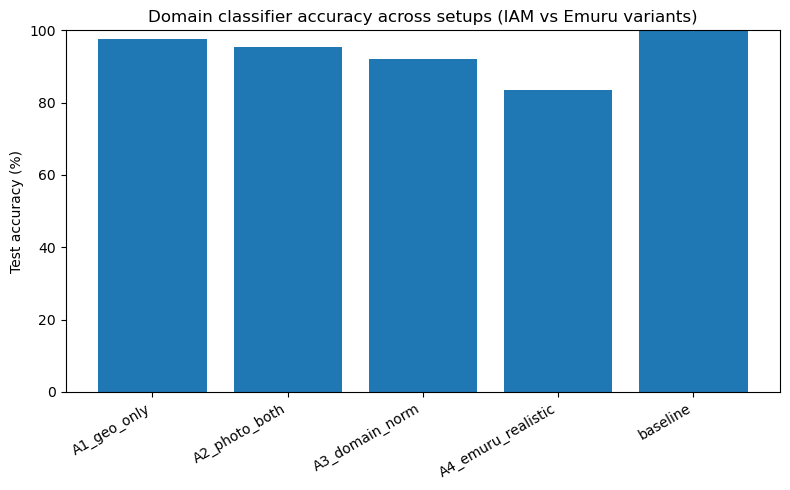

In [9]:
# Simple bar plot: test accuracy per model
plt.figure(figsize=(8, 5))

x = np.arange(len(summary_df))
accs = summary_df["test_acc"].values * 100.0

plt.bar(x, accs)
plt.xticks(x, summary_df.index, rotation=30, ha="right")
plt.ylabel("Test accuracy (%)")
plt.title("Domain classifier accuracy across setups (IAM vs Emuru variants)")
plt.ylim(0, 100)

plt.tight_layout()
plt.show()


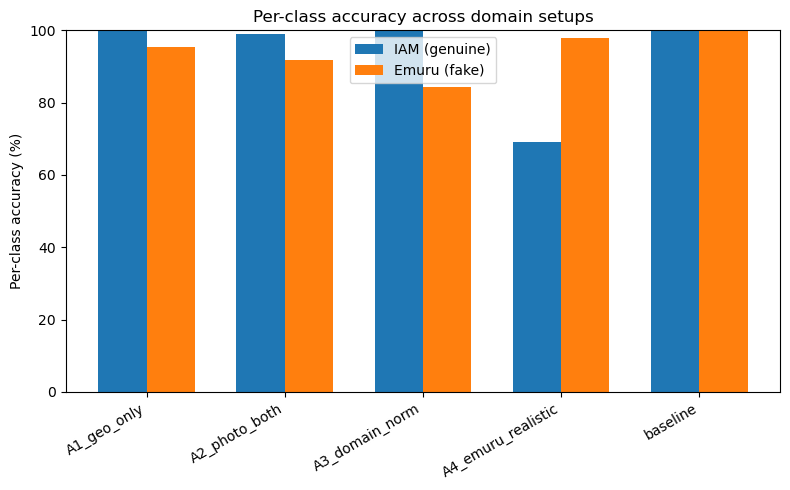

In [10]:
# Grouped bar chart: per-class acc per model
plt.figure(figsize=(8, 5))

x = np.arange(len(summary_df))
width = 0.35

acc_iam = summary_df["acc_iam"].values * 100.0
acc_emuru = summary_df["acc_emuru"].values * 100.0

plt.bar(x - width/2, acc_iam, width, label="IAM (genuine)")
plt.bar(x + width/2, acc_emuru, width, label="Emuru (fake)")

plt.xticks(x, summary_df.index, rotation=30, ha="right")
plt.ylabel("Per-class accuracy (%)")
plt.title("Per-class accuracy across domain setups")
plt.ylim(0, 100)
plt.legend()

plt.tight_layout()
plt.show()
